# Task 3-3: CNN on CIFAR-10 (PyTorch)

Similar to the [TensorFlow CIFAR-10 CNN tutorial](https://www.tensorflow.org/tutorials/images/cnn). https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

In [30]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [23]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_ds = datasets.CIFAR10(root="./data", train=True, transform=transform_train, download=True)
test_ds = datasets.CIFAR10(root="./data", train=False, transform=transform_test, download=True)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

In [25]:
# CNN similar to TF tutorial: Conv -> Conv -> MaxPool -> Dropout -> Flatten -> Dense -> Dense
class CIFAR10CNN(nn.Module):
    def __init__(self, num_classes=10, drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Dropout(drop), nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class CIFAR10CNN_BatchNorm(nn.Module):
    def __init__(self, num_classes=10, drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 4 * 4, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(drop), nn.Linear(512, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

In [26]:
def train_eval_cifar(model, train_loader, test_loader, epochs=6, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"test_loss": [], "test_acc": []}
    best_epoch, best_acc = 0, 0.0

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                total_loss += criterion(logits, labels).item() * images.size(0)
                correct += (logits.argmax(1) == labels).sum().item()
                total += images.size(0)
        test_loss = total_loss / total
        acc = 100.0 * correct / total
        history["test_loss"].append(test_loss)
        history["test_acc"].append(acc)
        if acc > best_acc:
            best_acc = acc
            best_epoch = epoch
    history["best_epoch"], history["best_acc"] = best_epoch, best_acc
    return history["test_loss"][-1], history["test_acc"][-1], history

In [27]:
# Compare: baseline CNN, higher dropout, BatchNorm variant, different LR
EPOCHS = 20
results_cifar = []
histories_cifar = []

torch.manual_seed(42)
m = CIFAR10CNN(drop=0.25)
loss, acc, hist = train_eval_cifar(m, train_loader, test_loader, epochs=EPOCHS)
results_cifar.append({"Config": "CNN (drop=0.25)", "Test Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories_cifar.append(("CNN (drop=0.25)", hist))
print(f"CNN (drop=0.25): best accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']}")

torch.manual_seed(42)
m = CIFAR10CNN(drop=0.5)
loss, acc, hist = train_eval_cifar(m, train_loader, test_loader, epochs=EPOCHS)
results_cifar.append({"Config": "CNN (drop=0.5)", "Test Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories_cifar.append(("CNN (drop=0.5)", hist))
print(f"CNN (drop=0.5): best accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']}")

torch.manual_seed(42)
m = CIFAR10CNN_BatchNorm(drop=0.25)
loss, acc, hist = train_eval_cifar(m, train_loader, test_loader, epochs=EPOCHS)
results_cifar.append({"Config": "CNN + BatchNorm", "Test Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories_cifar.append(("CNN + BatchNorm", hist))
print(f"CNN + BatchNorm: best accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']}")

torch.manual_seed(42)
m = CIFAR10CNN(drop=0.25)
loss, acc, hist = train_eval_cifar(m, train_loader, test_loader, epochs=EPOCHS, lr=5e-4)
results_cifar.append({"Config": "CNN (lr=5e-4)", "Test Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories_cifar.append(("CNN (lr=5e-4)", hist))
print(f"CNN (lr=5e-4): best accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']}")

CNN (drop=0.25): best accuracy 78.40% at epoch 17
CNN (drop=0.5): best accuracy 67.40% at epoch 19
CNN + BatchNorm: best accuracy 83.75% at epoch 19
CNN (lr=5e-4): best accuracy 80.26% at epoch 19


In [28]:
df_cifar = pd.DataFrame(results_cifar)
df_cifar

,Config,Test Loss,Accuracy %,Best epoch
0,CNN (drop=0.25),0.635350,77.87,17
1,CNN (drop=0.5),0.923909,67.40,19
2,CNN + BatchNorm,0.471614,83.75,19
3,CNN (lr=5e-4),0.575997,80.26,19


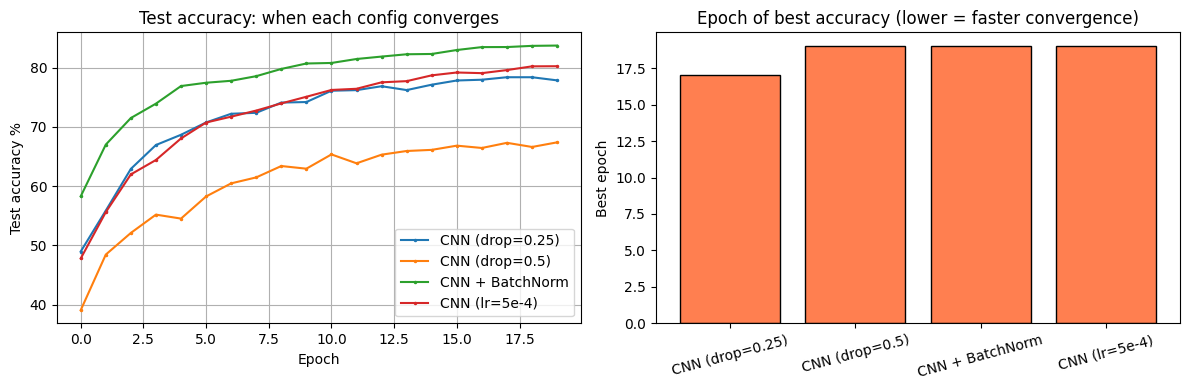

Best config by final accuracy: CNN + BatchNorm (83.75%)


In [29]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
names = [h[0] for h in histories_cifar]
for name, hist in histories_cifar:
    ep = range(len(hist["test_acc"]))
    ax1.plot(ep, hist["test_acc"], label=name, marker=".", markersize=3)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Test accuracy %")
ax1.set_title("Test accuracy: when each config converges")
ax1.legend(); ax1.grid(True)
best_epochs = [h[1]["best_epoch"] for h in histories_cifar]
ax2.bar(names, best_epochs, color="coral", edgecolor="black")
ax2.set_ylabel("Best epoch"); ax2.set_title("Epoch of best accuracy (lower = faster convergence)")
ax2.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
best_cfg = max(histories_cifar, key=lambda x: x[1]["best_acc"])
print(f"Best config by final accuracy: {best_cfg[0]} ({best_cfg[1]['best_acc']:.2f}%)")